In [1]:
# === 0) new Initialisierung ===

# ===============================================
# Analyse von IOI-Verhältnissen zur Beat-Detektion 
# ===============================================

# =============================
# 0) Imports
# =============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.integrate import simpson
from scipy.signal import argrelextrema
from fractions import Fraction
from collections import Counter
from functools import reduce
from math import gcd

# =============================
# 1) Proximity-Funktion
# =============================
def proximity_max_freq(
    x,
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
):
    x = np.array(x)
    freqs = np.arange(1, max_freq + 1)
    all_freq_values = []

    for freq in freqs:
        weight = 1.0 / (freq ** weight_exponent)
        freq_sharpness_base = sharpness_base * (freq ** freq_sharpness_exp)
        freq_sharpness_growth = sharpness_growth * (freq ** freq_sharpness_exp)

        sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness

        peak_sharpness = freq_sharpness_base * (norm_x ** freq_sharpness_growth)
        peak_value = ((1 + np.cos(2 * np.pi * freq * norm_x)) / 2) ** peak_sharpness
        peak_value = np.where(peak_value == 0, 1e-12, peak_value)

        denom = np.where(x == 0, 1e-12, x ** decay)
        val = weight * (cos_term / peak_value) / denom
        all_freq_values.append(val)

    all_freq_values = np.array(all_freq_values)
    peak_indices = np.argmax(all_freq_values, axis=0)
    proximity_max = np.max(all_freq_values, axis=0)

    max_at_norm_x = np.max([
        (1.0 / (freq ** weight_exponent)) * 1.0 / (norm_x ** decay)
        for freq in freqs
    ])
    proximity_max = proximity_max / max_at_norm_x * output_max
    return proximity_max, peak_indices, freqs

# =============================
# 2) Hilfsfunktionen
# =============================
def build_pairwise_proximity_df(iois, params, threshold=0.01):
    n = len(iois)
    ratios = np.array([[max(iois[i], iois[j]) / min(iois[i], iois[j]) 
                        for j in range(n)] for i in range(n)])
    prox_max, peak_idx, freqs = proximity_max_freq(ratios, **params)

    rows = []
    for i in range(n):
        for j in range(i + 1, n):
            r = float(ratios[i, j])
            s = float(prox_max[i, j])
            if s > threshold:
                best_f = int(freqs[peak_idx[i, j]])
                p = int(round(r * best_f))
                frac = Fraction(p, best_f)
                label = f"{frac.numerator}/{frac.denominator}"
            else:
                label = "Keine Proximity"

            rows.append({
                "i": i,
                "j": j,
                "ioi_i": float(iois[i]),
                "ioi_j": float(iois[j]),
                "ratio": r,
                "proximity": s,
                "peak_label": label
            })

    df_pairs = pd.DataFrame(rows)
    return df_pairs, ratios, prox_max

def generate_beat_candidates_from_iois(iois, min_ioi=0.01, max_ioi=6.0, resolution=0.01, max_denominator=48):
    raster = np.arange(min_ioi, max_ioi + 1e-12, resolution)
    candidates = set(np.round(raster, 6))
    for ioi in iois:
        if ioi < min_ioi or ioi > max_ioi:
            continue
        for denom in range(1, max_denominator + 1):
            beat = ioi / denom
            if min_ioi <= beat <= max_ioi:
                candidates.add(float(Fraction(beat).limit_denominator(1000)))
    for denom in range(1, max_denominator + 1):
        val = 1.0 / denom
        if min_ioi <= val <= max_ioi:
            candidates.add(float(Fraction(val).limit_denominator(1000)))
    return sorted(candidates)

def score_for_beat(beat, iois, params):
    ratios = np.maximum(iois, beat) / np.minimum(iois, beat)
    prox_vals, _, _ = proximity_max_freq(ratios, **params)
    return float(np.mean(prox_vals))

def find_local_maxima(candidates, scores, order=5):
    indices = argrelextrema(np.array(scores), np.greater, order=order)[0]
    return [(candidates[i], scores[i]) for i in indices]

# =============================
# 3) Parameter
# =============================
params = dict(
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
)
PAIR_THRESHOLD = 0.01

✅ S_bil_IC_p23_12.csv in Bat Saccopteryx bilineata (S_bil) → avg_prox=0.3022
✅ S_bil_IC_p23_06.csv in Bat Saccopteryx bilineata (S_bil) → avg_prox=0.3011
✅ S_bil_IC_p21_2.csv in Bat Saccopteryx bilineata (S_bil) → avg_prox=0.1667
✅ S_bil_IC_p21_16.csv in Bat Saccopteryx bilineata (S_bil) → avg_prox=0.2972
✅ S_bil_IC_p21_14.csv in Bat Saccopteryx bilineata (S_bil) → avg_prox=0.2671
✅ S_bil_IC_p24_18.csv in Bat Saccopteryx bilineata (S_bil) → avg_prox=0.3917
✅ S_bil_IC_p23_10.csv in Bat Saccopteryx bilineata (S_bil) → avg_prox=0.1908
✅ S_bil_IC_p23_04.csv in Bat Saccopteryx bilineata (S_bil) → avg_prox=0.2336
✅ S_bil_IC_p23_14.csv in Bat Saccopteryx bilineata (S_bil) → avg_prox=0.1866
✅ S_bil_IC_p24_08.csv in Bat Saccopteryx bilineata (S_bil) → avg_prox=0.3783
✅ S_bil_IC_p24_20.csv in Bat Saccopteryx bilineata (S_bil) → avg_prox=0.3808
✅ S_bil_IC_p21_4.csv in Bat Saccopteryx bilineata (S_bil) → avg_prox=0.2816
✅ S_bil_IC_p21_10.csv in Bat Saccopteryx bilineata (S_bil) → avg_prox=0.2786
✅

,folder,file,avg_proximity,best_beat,best_score
0,Bat Saccopteryx bilineata (S_bil),S_bil_IC_p23_12.csv,0.302221,0.075200,0.503533
1,Bat Saccopteryx bilineata (S_bil),S_bil_IC_p23_06.csv,0.301065,0.096501,0.631757
2,Bat Saccopteryx bilineata (S_bil),S_bil_IC_p21_2.csv,0.166734,0.060606,0.370990
3,Bat Saccopteryx bilineata (S_bil),S_bil_IC_p21_16.csv,0.297212,0.070000,0.515545
4,Bat Saccopteryx bilineata (S_bil),S_bil_IC_p21_14.csv,0.267068,0.073899,0.419814


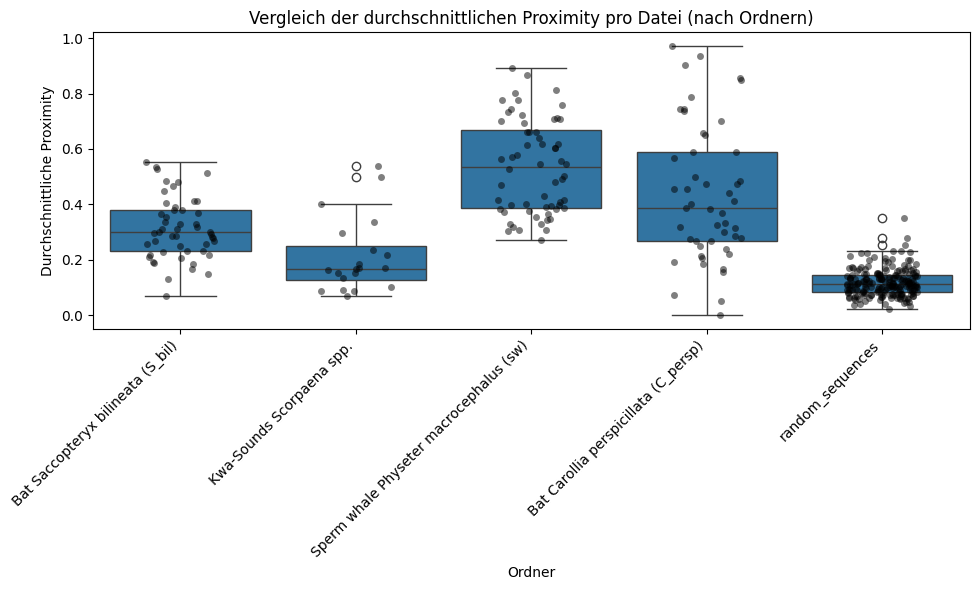

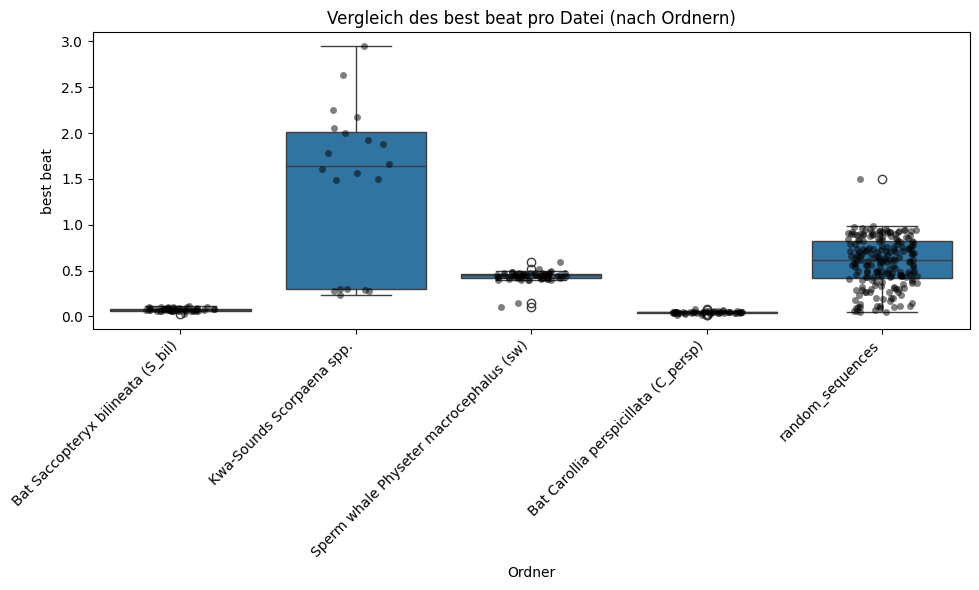

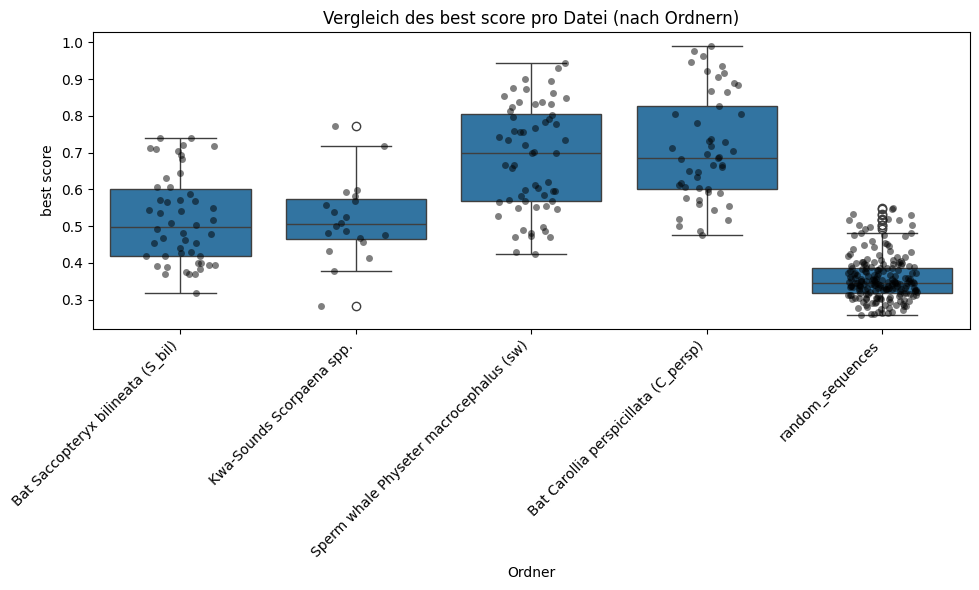

In [2]:
results = []

main_dir = Path("../data")

skip_folders = ["theoretical_sequences"]

for file in main_dir.rglob("*.csv"):   # durchsucht alle Unterordner
    try:
        # Skip falls Datei in einem Skip-Ordner liegt
        if any(skip in file.parts for skip in skip_folders):
            continue

        # Ordnername als "folder" nehmen (Elternordner der Datei)
        folder_name = file.parent.name

        df = pd.read_csv(file)
        if "IOI" not in df.columns:
            continue

        iois = df["IOI"].dropna().values
        onsets = df["onset"].dropna().values if "onset" in df.columns else None

        beat_candidates = generate_beat_candidates_from_iois(iois)  
        scores = [score_for_beat(beat, iois, params) for beat in beat_candidates]
        
        local_maxima = find_local_maxima(beat_candidates, scores, order=5)
        local_maxima_top1 = sorted(local_maxima, key=lambda x: -x[1])[:1]

        # optional: direkt die Werte extrahieren, falls du nur Beat und Score brauchst
        if local_maxima_top1:
            best_beat, best_score = local_maxima_top1[0]
        else:
            best_beat, best_score = None, None

        df_pairs, _, _ = build_pairwise_proximity_df(iois, params, threshold=PAIR_THRESHOLD)
        avg_prox = df_pairs["proximity"].mean()

        results.append({
            "folder": folder_name,
            "file": file.name,
            "avg_proximity": avg_prox,
            "best_beat": best_beat,
            "best_score": best_score
        })

        print(f"✅ {file.name} in {folder_name} → avg_prox={avg_prox:.4f}")

    except Exception as e:
        print(f"⚠️ Fehler bei Datei {file}: {e}")

# =============================
# 3) Random-Sequenzen hinzufügen
# =============================

# Anzahl der Random-Sequenzen
n_seq = 200
seq_len = 10

# Ergebnisse für Random-Sequenzen
for _ in range(n_seq):
    iois = np.random.rand(seq_len)  # Zufällige IOIs
    
    # Optional: generate beat candidates und score berechnen wie bei echten Daten
    beat_candidates = generate_beat_candidates_from_iois(iois)
    scores = [score_for_beat(beat, iois, params) for beat in beat_candidates]
    local_maxima = find_local_maxima(beat_candidates, scores, order=5)
    local_maxima_top1 = sorted(local_maxima, key=lambda x: -x[1])[:1]

    if local_maxima_top1:
        best_beat, best_score = local_maxima_top1[0]
    else:
        best_beat, best_score = None, None

    # Proximity berechnen
    df_pairs, _, _ = build_pairwise_proximity_df(iois, params, threshold=PAIR_THRESHOLD)
    avg_prox = df_pairs["proximity"].mean()

    # In die Ergebnisse aufnehmen
    results.append({
        "folder": "random_sequences",
        "file": "random_seq",
        "avg_proximity": avg_prox,
        "best_beat": best_beat,
        "best_score": best_score
    })

# Danach wie gehabt DataFrame erstellen
df_results = pd.DataFrame(results)

# =============================
# 4) Ergebnisse anzeigen
# =============================

if df_results.empty:
    print("⚠️ Keine Ergebnisse – überprüfe die IOI-Spalte oder Dateistruktur!")
else:
    print("✅ Ergebnisse gesammelt")
    display(df_results.head())

    # Boxplot der durchschnittlichen Proximity pro Datei (nach Ordnern)
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_results, x="folder", y="avg_proximity")
    sns.stripplot(data=df_results, x="folder", y="avg_proximity",
                  color="black", alpha=0.5, jitter=0.2)
    plt.xticks(rotation=45, ha="right")
    plt.title("Vergleich der durchschnittlichen Proximity pro Datei (nach Ordnern)")
    plt.ylabel("Durchschnittliche Proximity")
    plt.xlabel("Ordner")
    plt.tight_layout()
    plt.show()

    # Boxplot der durchschnittlichen best beat pro Datei (nach Ordnern)
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_results, x="folder", y="best_beat")
    sns.stripplot(data=df_results, x="folder", y="best_beat",
                  color="black", alpha=0.5, jitter=0.2)
    plt.xticks(rotation=45, ha="right")
    plt.title("Vergleich des best beat pro Datei (nach Ordnern)")
    plt.ylabel("best beat")
    plt.xlabel("Ordner")
    plt.tight_layout()
    plt.show()

    # Boxplot der durchschnittlichen best score pro Datei (nach Ordnern)
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_results, x="folder", y="best_score")
    sns.stripplot(data=df_results, x="folder", y="best_score",
                  color="black", alpha=0.5, jitter=0.2)
    plt.xticks(rotation=45, ha="right")
    plt.title("Vergleich des best score pro Datei (nach Ordnern)")
    plt.ylabel("best score")
    plt.xlabel("Ordner")
    plt.tight_layout()
    plt.show()